# Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE

In [2]:
random_state = 42

# Data Description

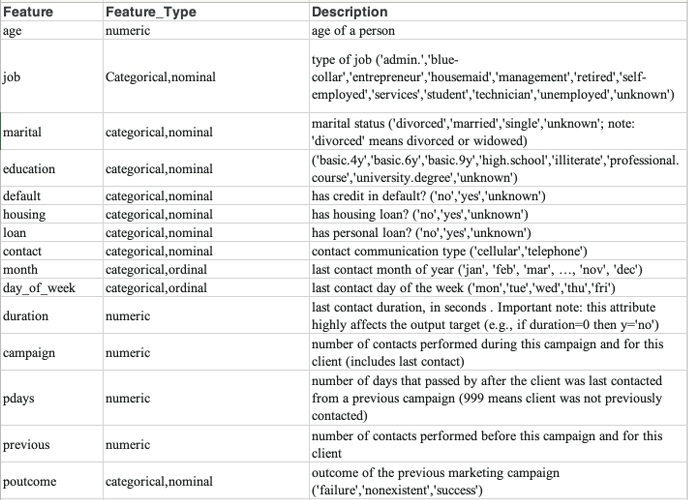

# Load Data

In [3]:
df = pd.read_csv('Dataset/data_1C.csv', index_col=0)

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,29,technician,single,basic.9y,no,yes,no,cellular,nov,wed,648.0,1,999,0,nonexistent,no
1,31,admin.,single,university.degree,no,no,no,cellular,aug,wed,295.0,1,999,0,nonexistent,no
2,27,blue-collar,single,basic.9y,no,yes,no,telephone,jul,mon,236.0,2,999,0,nonexistent,no
3,30,services,married,unknown,no,no,no,telephone,may,wed,143.0,3,999,0,nonexistent,no
4,32,technician,married,university.degree,no,no,no,cellular,aug,thu,155.0,1,999,0,nonexistent,no


# Preprocess data based on the description

- `Month` and `day_of_week` can be represented by `duration`
- Treat `unknown` value as missing value
- Set not contatcted as -1 in `pdays`

In [4]:
new_df = df.drop(columns=['month', 'day_of_week'], axis=1)

# Treat every unknown value as a missing value
new_df = new_df.replace('unknown', np.nan)

new_df['pdays'] = new_df['pdays'].replace(999, -1)

# EDA

## Data Type

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8237 entries, 0 to 8236
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          8237 non-null   int64  
 1   job          8227 non-null   object 
 2   marital      8237 non-null   object 
 3   education    8237 non-null   object 
 4   default      8237 non-null   object 
 5   housing      8237 non-null   object 
 6   loan         8237 non-null   object 
 7   contact      8237 non-null   object 
 8   month        8237 non-null   object 
 9   day_of_week  8237 non-null   object 
 10  duration     8222 non-null   float64
 11  campaign     8237 non-null   int64  
 12  pdays        8237 non-null   int64  
 13  previous     8237 non-null   int64  
 14  poutcome     8237 non-null   object 
 15  y            8237 non-null   object 
dtypes: float64(1), int64(4), object(11)
memory usage: 1.1+ MB


## Missing Value

In [6]:
new_df.isna().sum()

age             0
job            73
marital        13
education     328
default      1701
housing       199
loan          199
contact         0
duration       15
campaign        0
pdays           0
previous        0
poutcome        0
y               0
dtype: int64

We will do the following steps to handle missing values:

- Numerical: fill with median
- Categorical: fill with mode

## Distribution

In [7]:
numerical_features = new_df.select_dtypes(include=[np.number]).columns
categorical_features = new_df.select_dtypes(include=[object]).columns


### Numerical

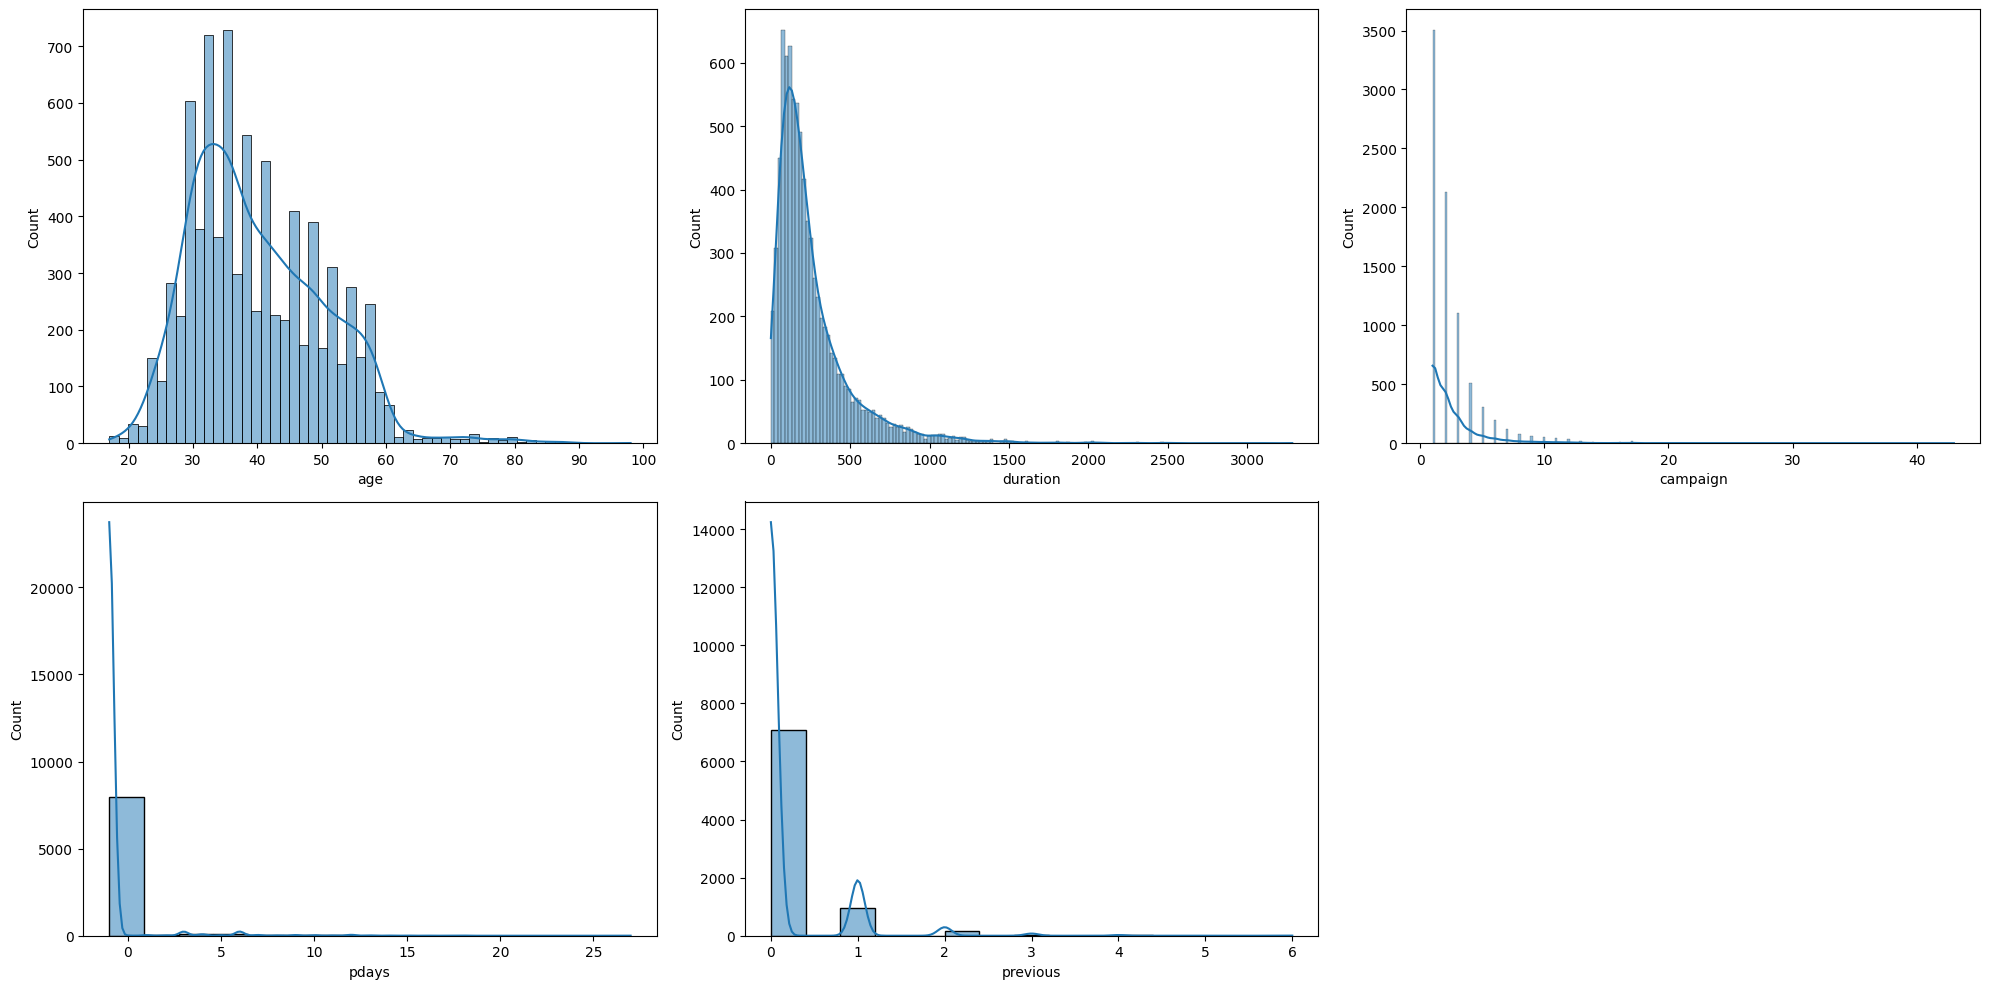

In [8]:
fig = plt.figure(figsize=(20, 10))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(new_df[col], kde=True)
    plt.xlabel(col)
    
plt.tight_layout()
plt.show()

The data is highly imbalanced, we will use SMOTE to balance the data

### Categorical

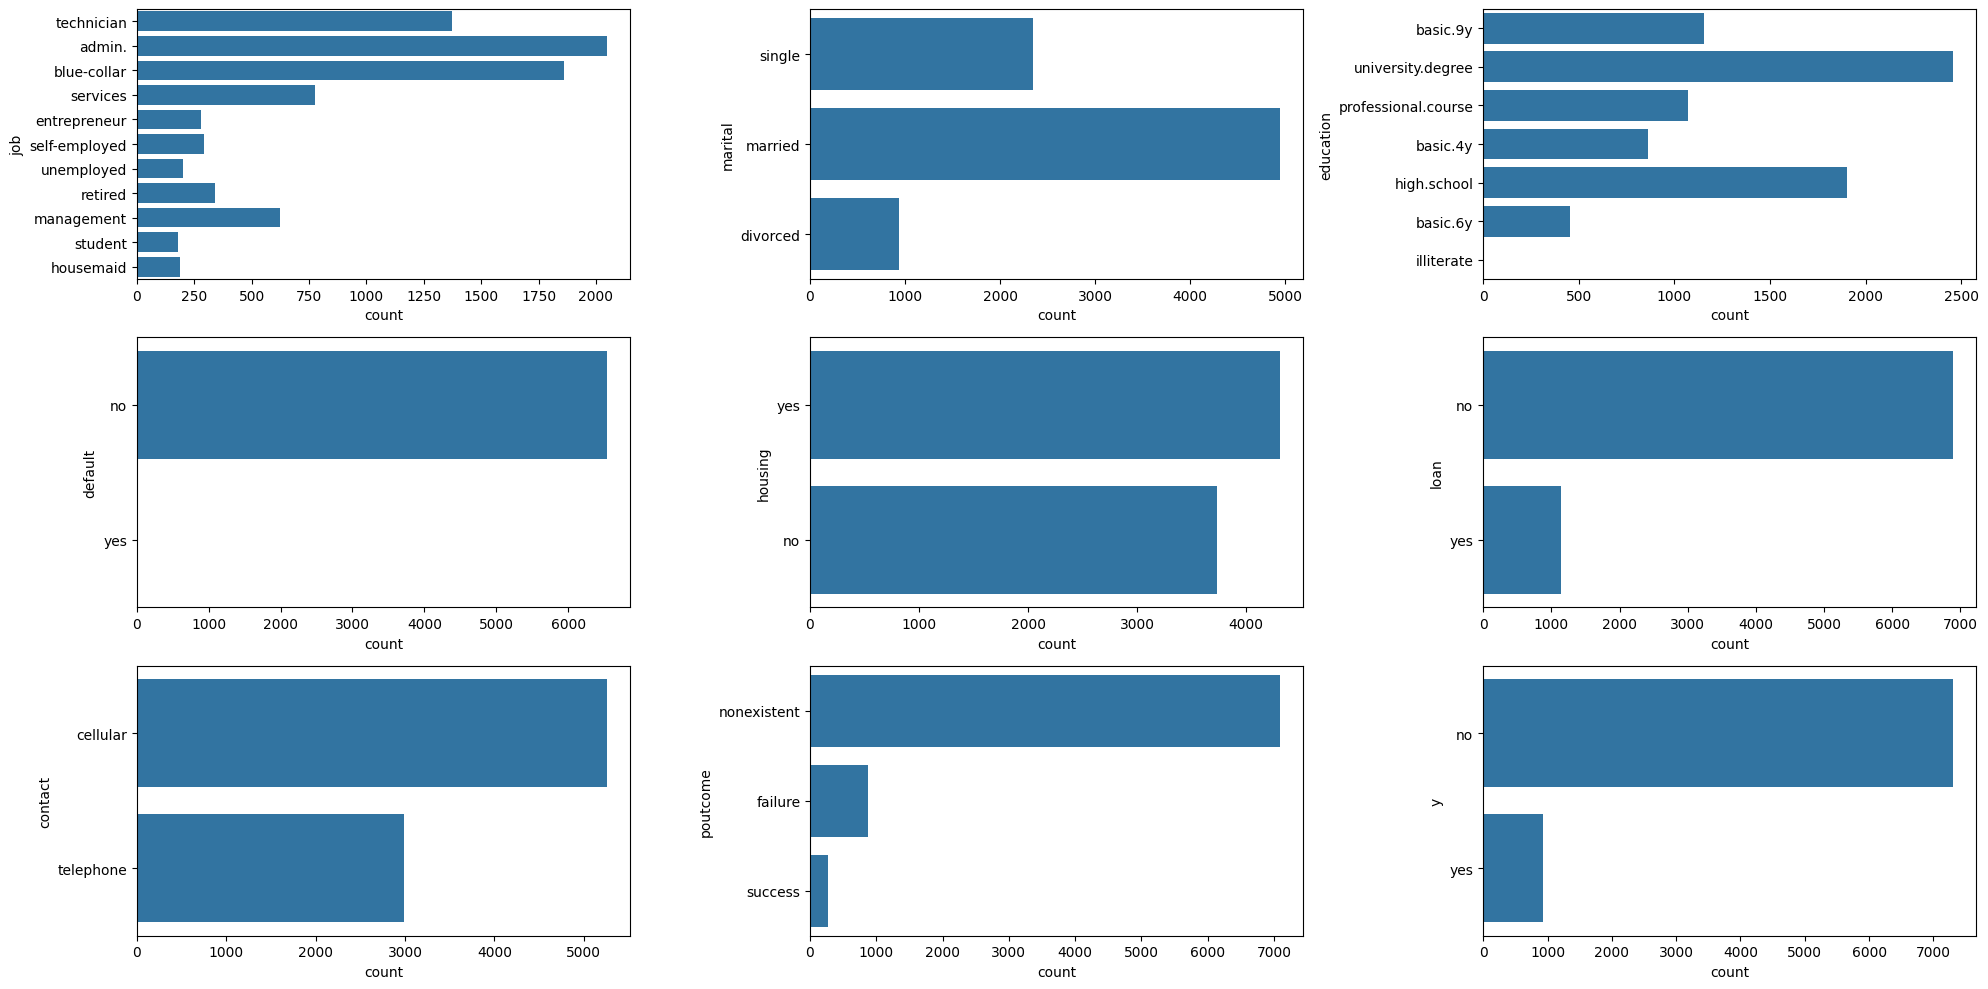

In [9]:
fig = plt.figure(figsize=(20, 10))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i)
    sns.countplot(y=new_df[col])
    plt.ylabel(col)
    
plt.tight_layout()
plt.show()

The data is highly imbalanced, we will use SMOTE to balance the data. We will also use one-hot encoding to encode the categorical data.

## Feature Engineering

### Make dummy dataset

In [10]:
temp_data = new_df.copy()

### Create dummy variables

In [11]:
encoder = OrdinalEncoder()

temp_data[categorical_features] = encoder.fit_transform(temp_data[categorical_features])
temp_data.dropna(inplace=True)

temp_data.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,y
0,29,9.0,2.0,2.0,0.0,1.0,0.0,0.0,648.0,1,-1,0,1.0,0.0
1,31,0.0,2.0,6.0,0.0,0.0,0.0,0.0,295.0,1,-1,0,1.0,0.0
2,27,1.0,2.0,2.0,0.0,1.0,0.0,1.0,236.0,2,-1,0,1.0,0.0
4,32,9.0,1.0,6.0,0.0,0.0,0.0,0.0,155.0,1,-1,0,1.0,0.0
5,37,9.0,2.0,5.0,0.0,1.0,0.0,0.0,286.0,2,-1,0,1.0,0.0


### Heatmap

<Axes: >

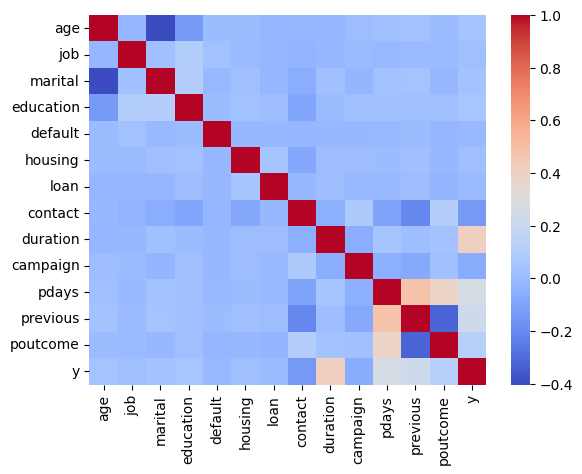

In [12]:
sns.heatmap(temp_data.corr(), cmap='coolwarm', fmt='.2f')

- `previous` and `poutcome` are highly correlated, we will drop `poutcome`
- `marital` and `age` are highly correlated, we will drop `age`

# Preprocessing

## Drop multicollinear features

In [13]:
new_df = new_df.drop(columns=['poutcome', 'age'])

## Split data

In [14]:
X, y = new_df.drop(columns='y'), new_df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

## Impute missing values

In [15]:
for col in X_train.columns :
    if X_train[col].dtype == 'object' :
        X_train[col] = X_train[col].fillna(X_train[col].mode()[0])
        X_test[col] = X_test[col].fillna(X_test[col].mode()[0])   
    else :
        X_train[col] = X_train[col].fillna(X_train[col].median())
        X_test[col] = X_test[col].fillna(X_test[col].median())

## Scale data

In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_num = X_train.select_dtypes(include=[np.number])
test_num = X_test.select_dtypes(include=[np.number])

train_num = scaler.fit_transform(train_num)
test_num = scaler.transform(test_num)

train_num = pd.DataFrame(train_num, columns=X_train.select_dtypes(include=[np.number]).columns)
test_num = pd.DataFrame(test_num, columns=X_test.select_dtypes(include=[np.number]).columns)

## Encode categorical data

In [17]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

train_cat = X_train.select_dtypes(include=[object])
test_cat = X_test.select_dtypes(include=[object])

train_cat = encoder.fit_transform(train_cat)
test_cat = encoder.transform(test_cat)

train_cat = pd.DataFrame(train_cat, columns=X_train.select_dtypes(include=[object]).columns)
test_cat = pd.DataFrame(test_cat, columns=X_test.select_dtypes(include=[object]).columns)

In [18]:
X_train = pd.concat([train_num, train_cat], axis=1)
X_test = pd.concat([test_num, test_cat], axis=1)

## SMOTE

In [21]:
balancer = SMOTE(random_state=random_state)

X_train, y_train = balancer.fit_resample(X_train, y_train)

# Model

## Decision Tree

### Base Model

In [29]:
dt_tree = DecisionTreeClassifier(random_state=random_state)

dt_tree.fit(X_train, y_train)

y_pred = dt_tree.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.93      0.90      0.91      1464
         yes       0.36      0.47      0.41       184

    accuracy                           0.85      1648
   macro avg       0.65      0.68      0.66      1648
weighted avg       0.87      0.85      0.86      1648



### Hyperparameter Tuning

In [32]:
# Hyperparameter tuning with GridSearchCV

param_grid = {
    'max_depth': np.arange(1, 10),
    'min_samples_split': np.arange(2, 10),
    'min_samples_leaf': np.arange(1, 10)
}

grid_search = GridSearchCV(estimator=dt_tree, param_grid=param_grid, cv=5, n_jobs=-1, verbose=3)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
{'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 5}


### Tuned Model

In [33]:
tuned_dt_tree = grid_search.best_estimator_

y_pred = tuned_dt_tree.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.95      0.87      0.91      1464
         yes       0.38      0.62      0.47       184

    accuracy                           0.85      1648
   macro avg       0.66      0.75      0.69      1648
weighted avg       0.88      0.85      0.86      1648



### Get Feature Importance

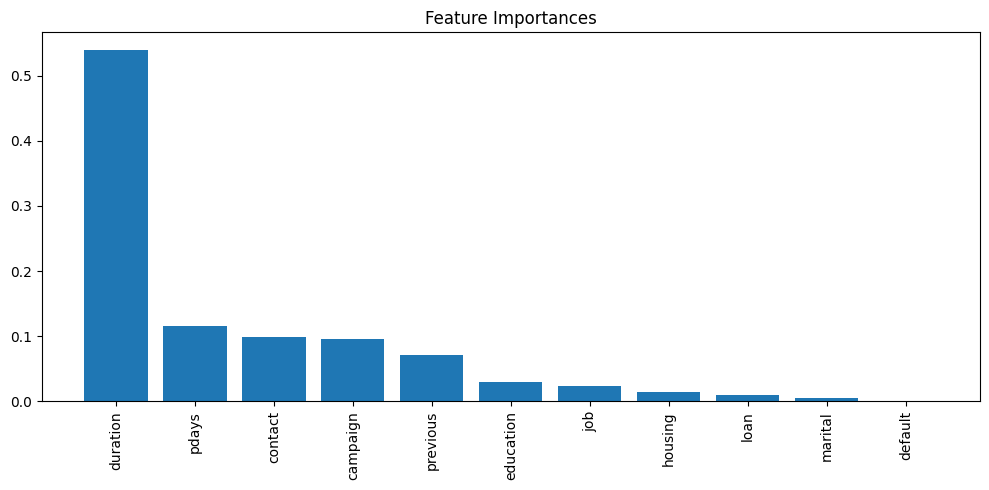

In [34]:
# Feature importance

importances = tuned_dt_tree.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

using only the top 5 features

In [35]:
selected_X_train = X_train.iloc[:, indices[:5]]
selected_X_test = X_test.iloc[:, indices[:5]]

tuned_dt_tree.fit(selected_X_train, y_train)

y_pred = tuned_dt_tree.predict(selected_X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.95      0.90      0.92      1464
         yes       0.43      0.62      0.51       184

    accuracy                           0.86      1648
   macro avg       0.69      0.76      0.71      1648
weighted avg       0.89      0.86      0.88      1648



### Retune Model

In [38]:
grid_search = GridSearchCV(estimator=dt_tree, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(selected_X_train, y_train)

print(grid_search.best_params_)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
{'max_depth': 9, 'min_samples_leaf': 7, 'min_samples_split': 2}


### Tuned Decision Tree

In [40]:
tuned_dt_tree = grid_search.best_estimator_

y_pred = tuned_dt_tree.predict(selected_X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.95      0.89      0.92      1464
         yes       0.43      0.63      0.51       184

    accuracy                           0.87      1648
   macro avg       0.69      0.76      0.72      1648
weighted avg       0.89      0.87      0.88      1648



## Logistic Regression

### Base Model

In [99]:
log_reg = LogisticRegression(random_state=random_state, max_iter=1000)

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.96      0.83      0.89      1464
         yes       0.35      0.73      0.48       184

    accuracy                           0.82      1648
   macro avg       0.66      0.78      0.68      1648
weighted avg       0.89      0.82      0.85      1648



### Hyperparameter Tuning

In [100]:
param_grid = {
    'C': np.logspace(-3, 3, 7),
    'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'],
    'penalty': ['l2', None]
}

grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

Fitting 5 folds for each of 56 candidates, totalling 280 fits
{'C': 10.0, 'penalty': 'l2', 'solver': 'saga'}


### Tuned Logistic Regression Model

In [101]:
tuned_log_reg = grid_search.best_estimator_

y_pred = tuned_log_reg.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.96      0.83      0.89      1464
         yes       0.35      0.73      0.47       184

    accuracy                           0.82      1648
   macro avg       0.66      0.78      0.68      1648
weighted avg       0.89      0.82      0.84      1648



### Get Feature Importance

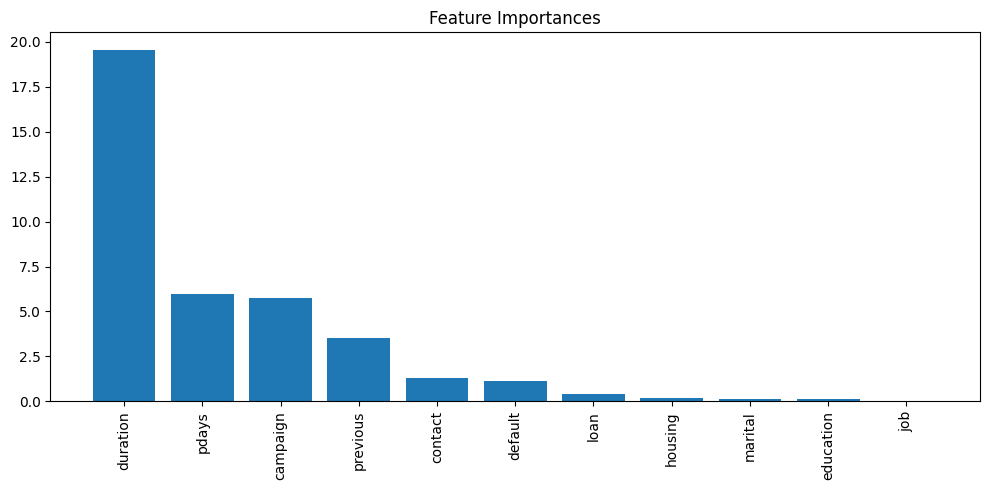

In [103]:
importances = np.abs(tuned_log_reg.coef_[0])

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

using only the top 5 features

In [104]:
selected_X_train = X_train.iloc[:, indices[:5]]
selected_X_test = X_test.iloc[:, indices[:5]]

### Retune Model

In [106]:
grid_search.fit(selected_X_train, y_train)

print(grid_search.best_params_)
tuned_log_reg = grid_search.best_estimator_

y_pred = tuned_log_reg.predict(selected_X_test)

print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 56 candidates, totalling 280 fits
{'C': 0.001, 'penalty': None, 'solver': 'sag'}
              precision    recall  f1-score   support

          no       0.96      0.83      0.89      1464
         yes       0.35      0.74      0.48       184

    accuracy                           0.82      1648
   macro avg       0.66      0.79      0.68      1648
weighted avg       0.89      0.82      0.84      1648



c:\Users\kanek\.conda\envs\Fast_API_Model_Deployment\Lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


## Random Forest

### Base Model

In [57]:
base_random_forest = RandomForestClassifier(random_state=random_state)

base_random_forest.fit(X_train, y_train)

y_pred = base_random_forest.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.94      0.93      0.93      1464
         yes       0.47      0.52      0.49       184

    accuracy                           0.88      1648
   macro avg       0.70      0.72      0.71      1648
weighted avg       0.89      0.88      0.88      1648



### Hyperparameter Tuning

In [48]:
param_grid = {
    'n_estimators': np.arange(100, 1000, 100),
    'max_depth': np.arange(1, 10),
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(estimator=random_forest, param_grid=param_grid, cv=5, n_jobs=-1, verbose=3)

%time grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
CPU times: total: 9.7 s
Wall time: 9min 39s
{'criterion': 'gini', 'max_depth': 9, 'n_estimators': 500}


In [49]:
tuned_random_forest = grid_search.best_estimator_

y_pred = tuned_random_forest.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.96      0.87      0.91      1464
         yes       0.41      0.72      0.52       184

    accuracy                           0.85      1648
   macro avg       0.69      0.79      0.72      1648
weighted avg       0.90      0.85      0.87      1648



### Feature Importance

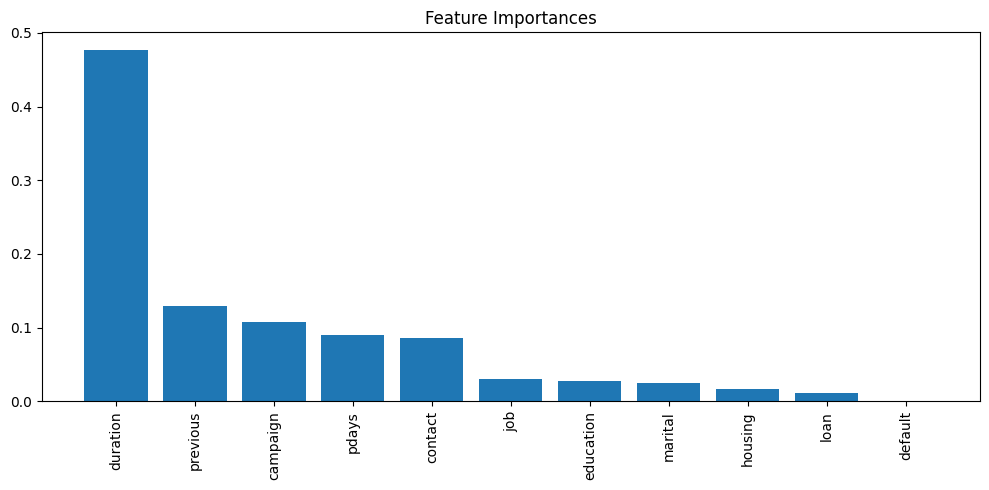

In [50]:
importances = tuned_random_forest.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.tight_layout()
plt.show()


use only the top 5 features

In [51]:
selected_X_train = X_train.iloc[:, indices[:5]]
selected_X_test = X_test.iloc[:, indices[:5]]

### Base Model with Top 5 Features

In [56]:
random_forest.fit(selected_X_train, y_train)

y_pred = random_forest.predict(selected_X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.94      0.90      0.92      1464
         yes       0.39      0.53      0.45       184

    accuracy                           0.86      1648
   macro avg       0.67      0.71      0.68      1648
weighted avg       0.88      0.86      0.87      1648



### Retune Model

In [54]:
grid_search = GridSearchCV(estimator=random_forest, param_grid=param_grid, cv=5, n_jobs=-1, verbose=3)

grid_search.fit(selected_X_train, y_train)

print(grid_search.best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
{'criterion': 'gini', 'max_depth': 9, 'n_estimators': 100}


In [55]:
retuned_random_forest = grid_search.best_estimator_

y_pred = retuned_random_forest.predict(selected_X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.95      0.88      0.92      1464
         yes       0.41      0.67      0.51       184

    accuracy                           0.86      1648
   macro avg       0.68      0.77      0.71      1648
weighted avg       0.89      0.86      0.87      1648



# Conclusion

From all of the model, the best model is Random Forest base model with all features. With precision of 0.47 or 47%. We selected precision because we want to minimize false positive, because false positive will mean wasted resources to the bank.

# Save Model

In [58]:
model_package = {
    'model' : base_random_forest,
    'scaler' : scaler,
    'encoder' : encoder
}

import joblib

joblib.dump(model_package, 'model_package.pkl')

['model_package.pkl']